In [8]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

key = os.environ.get("GROQ_API_KEY")
print(f"Key loaded: {key[:8]}...{key[-4:]}")  # safely prints partial key
print(f"Starts with gsk_: {key.startswith('gsk_')}")  # Groq keys must start with gsk_

Key loaded: gsk_w9bH...Dx1J
Starts with gsk_: True


In [24]:
import re
import json
import os
import yfinance as yf
from crewai import Agent, Task, Crew, Process, LLM
from crewai_tools import CodeInterpreterTool, FileReadTool

In [25]:
from pydantic import BaseModel, Field

class QueryAnalysisOutput(BaseModel):
    """Structured output for the query analysis task."""
    symbol: str = Field(..., description="Stock ticker symbol (e.g., TSLA, AAPL).")
    timeframe: str = Field(..., description="Time period (e.g., '1d', '1mo', '1y').")
    action: str = Field(..., description="Action to be performed (e.g., 'fetch', 'plot').")

In [28]:
llm = LLM(model="groq/llama-3.3-70b-versatile", api_key=os.environ.get("GROQ_API_KEY"))


# 1) Query parser agent
query_parser_agent = Agent(
    role="Stock Data Analyst",
    goal="Extract stock details and fetch required data from the user query:",
    backstory="You are a financial analyst specializing in stock market data retrieval.",
    llm=llm,
    verbose=True,
    memory=False,
)

query_parsing_task = Task(
    description="Analyze the user query and extract stock details.",
    expected_output="A dictionary with keys: 'symbol', 'timeframe', 'action'.",
    output_pydantic=QueryAnalysisOutput,
    agent=query_parser_agent,
)


# 2) Code writer agent
code_writer_agent = Agent(
    role="Senior Python Developer",
    goal="Write Python code to visualize stock data.",
    backstory="""You are a Senior Python developer specializing in stock market data visualization. 
                 You are also a Pandas, Matplotlib and yfinance library expert.
                 You are skilled at writing production-ready Python code""",
    llm=llm,
    verbose=True,
)

code_writer_task = Task(
    description="""Write Python code to visualize stock data based on the inputs from the stock analyst
                   where you would find stock symbol, timeframe and action.""",
    expected_output="A clean and executable Python script file (.py) for stock visualization.",
    agent=code_writer_agent,
)


# 3) Code interpreter agent (uses code interpreter tool from crewai)
code_interpreter_tool = CodeInterpreterTool()

code_execution_agent = Agent(
    role="Senior Code Execution Expert",
    goal="Review and execute the generated Python code by code writer agent to visualize stock data.",
    backstory="You are a code execution expert. You are skilled at executing Python code.",
    # tools=[code_interpreter_tool],
    allow_code_execution=True,   # This automatically adds the CodeInterpreterTool
    llm=llm,
    verbose=True,
)

code_execution_task = Task(
    description="""Review and execute the generated Python code by code writer agent to visualize stock data.""",
    expected_output="A clean and executable Python script file (.py) for stock visualization.",
    agent=code_execution_agent,
)

In [29]:
### --- CREW SETUP --- ###

crew = Crew(
    agents=[query_parser_agent, code_writer_agent, code_execution_agent],
    tasks=[query_parsing_task, code_writer_task, code_execution_task],
    process=Process.sequential
)

# Run the crew with an example query
result = crew.kickoff(inputs={"query": "Plot YTD stock gain of Tesla"})
print(result)

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Stock Data Analyst                                                                                      │
│                                                                                                                 │
│  Task: Analyze the user query and extract stock details.                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Stock Data Analyst                                                                                      │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {"symbol":"TSLA","timeframe":"1d","action":"fetch"}                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Python Developer                                                                                 │
│                                                                                                                 │
│  Task: Write Python code to visualize stock data based on the inputs from the stock analyst                     │
│                     where you would find stock symbol, timeframe and action.                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Python Developer                                                                                 │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```python                                                                                                      │
│  # Import necessary libraries                                                                                   │
│  import yfinance as yf                                                                                          │
│  import matplotlib.pyplot as plt                                                                                │
│  import pandas as pd                                                                                            │
│                                                                                                                 │
│  def visualize_stock_data(symbol, timeframe, action):                                                           │
│      """                                                                                                        │
│      This function fetches and visualizes stock data based on the given symbol, timeframe, and action.          │
│                                                                                                                 │
│      Args:                                                                                                      │
│          symbol (str): The stock symbol.                                                                        │
│          timeframe (str): The timeframe for which to fetch the data. Can be '1d', '5d', '1mo', '3mo', '6mo',    │
│  '1y', '2y', '5y', '10y', 'ytd', 'max'.                                                                         │
│          action (str): The action to perform. Can be 'fetch' or any other value.                                │
│                                                                                                                 │
│      Returns:                                                                                                   │
│          None                                                                                                   │
│      """                                                                                                        │
│                                                                                                                 │
│      # Check if the action is 'fetch'                                                                           │
│      if action != 'fetch':                                                                                      │
│          print("Invalid action. Only 'fetch' is supported.")                                                    │
│          return                                                                                                 │
│                                                                                                                 │
│      # Fetch the stock data                                                                                     │
│      try:                                                                                                       │
│          data = yf.download(symbol, period=timeframe)                                                           │
│      except Exception as e:                                                                                     │
│          print(f"Failed to fetch data for {symbol}: {st

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Code Execution Expert                                                                            │
│                                                                                                                 │
│  Task: Review and execute the generated Python code by code writer agent to visualize stock data.               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Code Execution Expert                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```python                                                                                                      │
│  # Import necessary libraries                                                                                   │
│  import yfinance as yf                                                                                          │
│  import matplotlib.pyplot as plt                                                                                │
│  import pandas as pd                                                                                            │
│                                                                                                                 │
│  def visualize_stock_data(symbol, timeframe, action):                                                           │
│      """                                                                                                        │
│      This function fetches and visualizes stock data based on the given symbol, timeframe, and action.          │
│                                                                                                                 │
│      Args:                                                                                                      │
│          symbol (str): The stock symbol.                                                                        │
│          timeframe (str): The timeframe for which to fetch the data. Can be '1d', '5d', '1mo', '3mo', '6mo',    │
│  '1y', '2y', '5y', '10y', 'ytd', 'max'.                                                                         │
│          action (str): The action to perform. Can be 'fetch' or any other value.                                │
│                                                                                                                 │
│      Returns:                                                                                                   │
│          None                                                                                                   │
│      """                                                                                                        │
│                                                                                                                 │
│      # Check if the action is 'fetch'                                                                           │
│      if action != 'fetch':                                                                                      │
│          print("Invalid action. Only 'fetch' is supported.")                                                    │
│          return                                                                                                 │
│                                                                                                                 │
│      # Fetch the stock data                                                                                     │
│      try:                                                                                                       │
│          data = yf.download(symbol, period=timeframe)                                                           │
│      except Exception as e:                                                                                     │
│          print(f"Failed to fetch data for {symbol}: {st

[CrewAIEventsBus] Warning: Event pairing mismatch. 'agent_execution_completed' closed 'llm_call_started' (expected 
'agent_execution_started')

[CrewAIEventsBus] Warning: Event pairing mismatch. 'task_completed' closed 'agent_execution_started' (expected 
'task_started')

[CrewAIEventsBus] Warning: Event pairing mismatch. 'crew_kickoff_completed' closed 'task_started' (expected 
'crew_kickoff_started')

```python
# Import necessary libraries
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

def visualize_stock_data(symbol, timeframe, action):
    """
    This function fetches and visualizes stock data based on the given symbol, timeframe, and action.

    Args:
        symbol (str): The stock symbol.
        timeframe (str): The timeframe for which to fetch the data. Can be '1d', '5d', '1mo', '3mo', '6mo', '1y', '2y', '5y', '10y', 'ytd', 'max'.
        action (str): The action to perform. Can be 'fetch' or any other value.

    Returns:
        None
    """

    # Check if the action is 'fetch'
    if action != 'fetch':
        print("Invalid action. Only 'fetch' is supported.")
        return

    # Fetch the stock data
    try:
        data = yf.download(symbol, period=timeframe)
    except Exception as e:
        print(f"Failed to fetch data for {symbol}: {str(e)}")
        return

    # Check if the data is empty
    if data.empty:
        print(f"No data 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Stock Data Analyst                                                                                      │
│                                                                                                                 │
│  Task: Analyze the user query and extract stock details.                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Stock Data Analyst                                                                                      │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {"symbol":"TSLA","timeframe":"1d","action":"fetch"}                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Python Developer                                                                                 │
│                                                                                                                 │
│  Task: Write Python code to visualize stock data based on the inputs from the stock analyst                     │
│                     where you would find stock symbol, timeframe and action.                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Python Developer                                                                                 │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```python                                                                                                      │
│  # Import necessary libraries                                                                                   │
│  import yfinance as yf                                                                                          │
│  import matplotlib.pyplot as plt                                                                                │
│  import pandas as pd                                                                                            │
│  import json                                                                                                    │
│                                                                                                                 │
│  def visualize_stock_data(stock_data):                                                                          │
│      """                                                                                                        │
│      This function fetches and visualizes stock data based on the given stock symbol, timeframe, and action.    │
│                                                                                                                 │
│      Args:                                                                                                      │
│          stock_data (dict): A dictionary containing the stock symbol, timeframe, and action.                    │
│                                                                                                                 │
│      Returns:                                                                                                   │
│          None                                                                                                   │
│      """                                                                                                        │
│                                                                                                                 │
│      # Extract the stock symbol, timeframe, and action from the input dictionary                                │
│      symbol = stock_data["symbol"]                                                                              │
│      timeframe = stock_data["timeframe"]                                                                        │
│      action = stock_data["action"]                                                                              │
│                                                                                                                 │
│      # Check if the action is 'fetch'                                                                           │
│      if action != 'fetch':                                                                                      │
│          print("Invalid action. Only 'fetch' is supported.")                                                    │
│          return                                                                                                 │
│                                                                                                                 │
│      # Fetch the stock data                                                                                     │
│      try:                                              

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Code Execution Expert                                                                            │
│                                                                                                                 │
│  Task: Review and execute the generated Python code by code writer agent to visualize stock data.               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Code Execution Expert                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```python                                                                                                      │
│  # Import necessary libraries                                                                                   │
│  import yfinance as yf                                                                                          │
│  import matplotlib.pyplot as plt                                                                                │
│  import pandas as pd                                                                                            │
│  import json                                                                                                    │
│                                                                                                                 │
│  def visualize_stock_data(stock_data):                                                                          │
│      """                                                                                                        │
│      This function fetches and visualizes stock data based on the given stock symbol, timeframe, and action.    │
│                                                                                                                 │
│      Args:                                                                                                      │
│          stock_data (dict): A dictionary containing the stock symbol, timeframe, and action.                    │
│                                                                                                                 │
│      Returns:                                                                                                   │
│          None                                                                                                   │
│      """                                                                                                        │
│                                                                                                                 │
│      # Extract the stock symbol, timeframe, and action from the input dictionary                                │
│      symbol = stock_data["symbol"]                                                                              │
│      timeframe = stock_data["timeframe"]                                                                        │
│      action = stock_data["action"]                                                                              │
│                                                                                                                 │
│      # Check if the action is 'fetch'                                                                           │
│      if action != 'fetch':                                                                                      │
│          print("Invalid action. Only 'fetch' is supported.")                                                    │
│          return                                                                                                 │
│                                                                                                                 │
│      # Fetch the stock data                                                                                     │
│      try:                                              

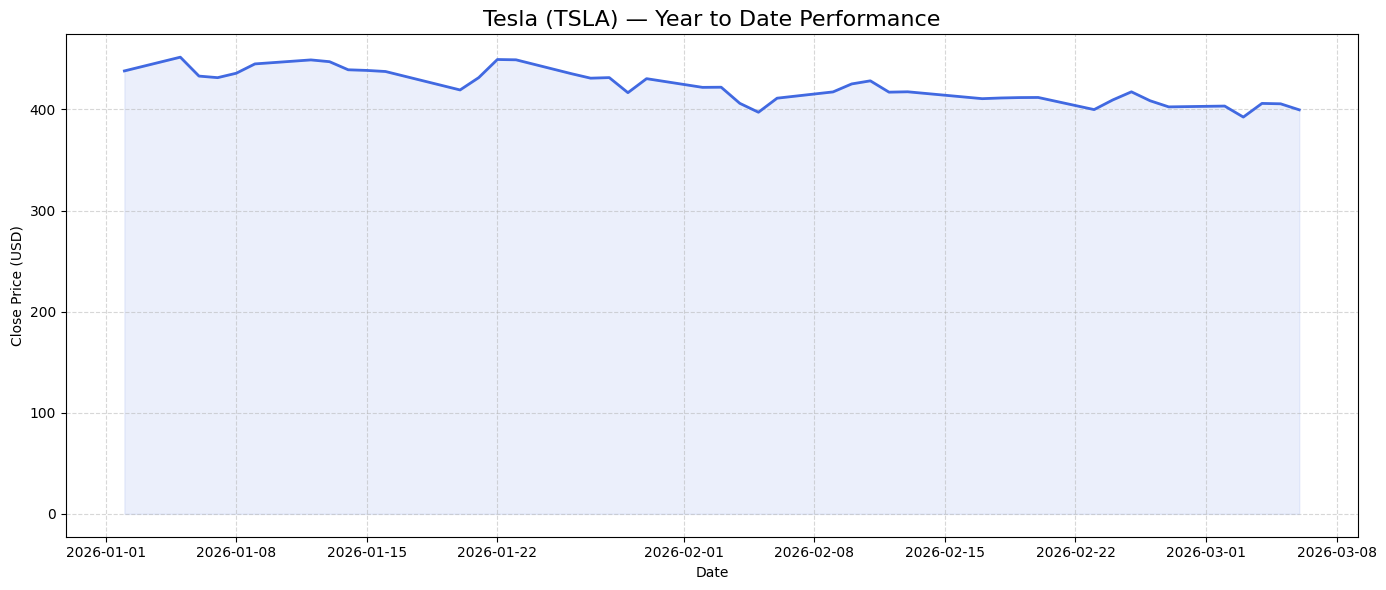


Crew Final Output: ```python
# Import necessary libraries
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import json

def visualize_stock_data(stock_data):
    """
    This function fetches and visualizes stock data based on the given stock symbol, timeframe, and action.

    Args:
        stock_data (dict): A dictionary containing the stock symbol, timeframe, and action.

    Returns:
        None
    """

    # Extract the stock symbol, timeframe, and action from the input dictionary
    symbol = stock_data["symbol"]
    timeframe = stock_data["timeframe"]
    action = stock_data["action"]

    # Check if the action is 'fetch'
    if action != 'fetch':
        print("Invalid action. Only 'fetch' is supported.")
        return

    # Fetch the stock data
    try:
        data = yf.download(symbol, period=timeframe)
    except Exception as e:
        print(f"Failed to fetch data for {symbol}: {str(e)}")
        return

    # Check if the data is empty
    if

In [30]:
result = crew.kickoff(inputs={"query": "Plot YTD stock gain of Tesla"})

# This actually renders the plot in the notebook
ticker = yf.Ticker("TSLA")
data = ticker.history(period="ytd")

plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'], color='royalblue', linewidth=2)
plt.fill_between(data.index, data['Close'], alpha=0.1, color='royalblue')
plt.title("Tesla (TSLA) — Year to Date Performance", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nCrew Final Output: {result.raw}")